# **Sales Performance Analysis**
This project analyzes superstore sales data to identify trends, profitability issues, and business opportunities.

## Data Exploration

In [1]:
import pandas as pd

# Loading the data
sales = pd.read_csv("Superstore.csv", encoding= 'latin1', index_col=0)





In [2]:
# Inspecting struture
sales.shape


(9994, 20)

In [3]:
sales.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9994 entries, 1 to 9994
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Order Date     9994 non-null   object 
 2   Ship Date      9994 non-null   object 
 3   Ship Mode      9994 non-null   object 
 4   Customer ID    9994 non-null   object 
 5   Customer Name  9994 non-null   object 
 6   Segment        9994 non-null   object 
 7   Country        9994 non-null   object 
 8   City           9994 non-null   object 
 9   State          9994 non-null   object 
 10  Postal Code    9994 non-null   int64  
 11  Region         9994 non-null   object 
 12  Product ID     9994 non-null   object 
 13  Category       9994 non-null   object 
 14  Sub-Category   9994 non-null   object 
 15  Product Name   9994 non-null   object 
 16  Sales          9994 non-null   float64
 17  Quantity       9994 non-null   int64  
 18  Discount     

In [5]:
# Previewing the data
# checking the first five rows
sales.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Row ID,,,,,,,,,,,,,,,,,,,,
1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


- The dataset has approximately 200,000 entries. It represents a retail business selling multiple product categories across regions

- Important Columns according to the Business Goal 
    - Sales- measure revenue
    - Profit- measure actual business success
    - Order date- for trend analysis
    - Region- show regional(geographic) perfomance
    - Category- helps group products

- One row represents **One Product** within an order


In [6]:
# Summary statistics
sales.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
sales[['Sales', 'Profit']].describe()

,Sales,Profit
count,9994.000000,9994.000000
mean,229.858001,28.656896
std,623.245101,234.260108
min,0.444000,-6599.978000
25%,17.280000,1.728750
50%,54.490000,8.666500
75%,209.940000,29.364000
max,22638.480000,8399.976000


- Some transactions result in losses, meaning certain products are not profitable

## Data Cleaning

In [ ]:
# checking missing values
sales.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

- No missing values

In [9]:
# checking duplicates
sales.duplicated().sum()

np.int64(1)

In [10]:
# drop duplicates
sales = sales.drop_duplicates()

In [11]:
# check again
sales.duplicated().sum()

np.int64(0)

In [12]:
# fixing data types
sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 1 to 9994
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9993 non-null   object 
 1   Order Date     9993 non-null   object 
 2   Ship Date      9993 non-null   object 
 3   Ship Mode      9993 non-null   object 
 4   Customer ID    9993 non-null   object 
 5   Customer Name  9993 non-null   object 
 6   Segment        9993 non-null   object 
 7   Country        9993 non-null   object 
 8   City           9993 non-null   object 
 9   State          9993 non-null   object 
 10  Postal Code    9993 non-null   int64  
 11  Region         9993 non-null   object 
 12  Product ID     9993 non-null   object 
 13  Category       9993 non-null   object 
 14  Sub-Category   9993 non-null   object 
 15  Product Name   9993 non-null   object 
 16  Sales          9993 non-null   float64
 17  Quantity       9993 non-null   int64  
 18  Discount     

In [13]:
# change the type of dates
sales['Order Date'] = pd.to_datetime(sales['Order Date'])
sales['Ship Date'] = pd.to_datetime(sales['Ship Date'])

In [14]:
sales[['Order Date', 'Ship Date']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 1 to 9994
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  9993 non-null   datetime64[ns]
 1   Ship Date   9993 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 234.2 KB


In [15]:
# Month amd Year columns for trend analysis
sales['Year'] = sales['Order Date'].dt.year
sales['Month'] = sales['Order Date'].dt.month_name()

In [16]:
sales[['Year', 'Month']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 1 to 9994
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Year    9993 non-null   int32 
 1   Month   9993 non-null   object
dtypes: int32(1), object(1)
memory usage: 195.2+ KB


In [17]:
sales[['Order Date', 'Year', 'Month']].head()

,Order Date,Year,Month
Row ID,,,
1,2016-11-08,2016,November
2,2016-11-08,2016,November
3,2016-06-12,2016,June
4,2015-10-11,2015,October
5,2015-10-11,2015,October


In [18]:
sales[['Order Date', 'Year', 'Month' ]].tail()

,Order Date,Year,Month
Row ID,,,
9990,2014-01-21,2014,January
9991,2017-02-26,2017,February
9992,2017-02-26,2017,February
9993,2017-02-26,2017,February
9994,2017-05-04,2017,May


In [19]:
# checking the temporal boundary of the data
sales['Year'].max()


np.int32(2017)

In [20]:
sales['Year'].min()

np.int32(2014)

In [21]:
# checking for strange values
sales[['Sales', 'Profit']].describe()

,Sales,Profit
count,9993.000000,9993.000000
mean,229.852846,28.660971
std,623.276074,234.271476
min,0.444000,-6599.978000
25%,17.280000,1.731000
50%,54.480000,8.671000
75%,209.940000,29.364000
max,22638.480000,8399.976000


In [22]:
sales[sales['Sales'] < 0]


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
Row ID,,,,,,,,,,,,,,,,,,,,,


In [23]:
sales[sales['Profit'] < 0]

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
Row ID,,,,,,,,,,,,,,,,,,,,,
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October
15,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,Texas,...,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580,2015,November
16,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,Texas,...,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3,0.80,-3.8160,2015,November
24,US-2017-156909,2017-07-16,2017-07-18,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,Pennsylvania,...,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196,2017,July
28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,Pennsylvania,...,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522,2015,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9921,CA-2016-149272,2016-03-15,2016-03-19,Standard Class,MY-18295,Muhammed Yedwab,Corporate,United States,Bryan,Texas,...,OFF-BI-10004233,Office Supplies,Binders,"GBC Pre-Punched Binding Paper, Plastic, White,...",22.3860,7,0.80,-35.8176,2016,March
9922,CA-2014-111360,2014-11-24,2014-11-30,Standard Class,AT-10435,Alyssa Tate,Home Office,United States,Akron,Ohio,...,OFF-BI-10003350,Office Supplies,Binders,Acco Expandable Hanging Binders,5.7420,3,0.70,-4.5936,2014,November
9932,CA-2015-104948,2015-11-13,2015-11-17,Standard Class,KH-16510,Keith Herrera,Consumer,United States,San Bernardino,California,...,FUR-BO-10004357,Furniture,Bookcases,O'Sullivan Living Dimensions 3-Shelf Bookcases,683.3320,4,0.15,-40.1960,2015,November


- No strange values
- Negative profit = Loss

In [24]:
# Checking for unique categories/ regions to identify them and check for inconsistency 
sales['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [25]:
sales['Region'].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

## Data Visualization

In [26]:
# Investigating how sales are changing over time
# Total revenue
sales['Sales'].sum()

np.float64(2296919.4883000003)

In [27]:
# sales over time
# group by date
sales_trend = sales.groupby('Order Date')['Sales'].sum()
sales_trend.head()

Order Date
2014-01-03      16.448
2014-01-04     288.060
2014-01-05      19.536
2014-01-06    4407.100
2014-01-07      87.158
Name: Sales, dtype: float64

In [28]:
sales['Month Number'] = pd.to_datetime(sales['Month'], format='%B').dt.month

In [29]:
monthly_sales = sales.groupby(['Year','Month Number'])['Sales'].sum().reset_index()
monthly_sales

,Year,Month Number,Sales
0,2014,1,14236.8950
1,2014,2,4519.8920
2,2014,3,55691.0090
3,2014,4,28013.9730
4,2014,5,23648.2870
5,2014,6,34595.1276
6,2014,7,33946.3930
7,2014,8,27909.4685
8,2014,9,81777.3508
9,2014,10,31453.3930


In [30]:
monthly_sales['Date'] = pd.to_datetime(
    monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month Number'].astype(str)
)

In [31]:
monthly_sales = monthly_sales.sort_values('Date')

### Sales Trend Over Time

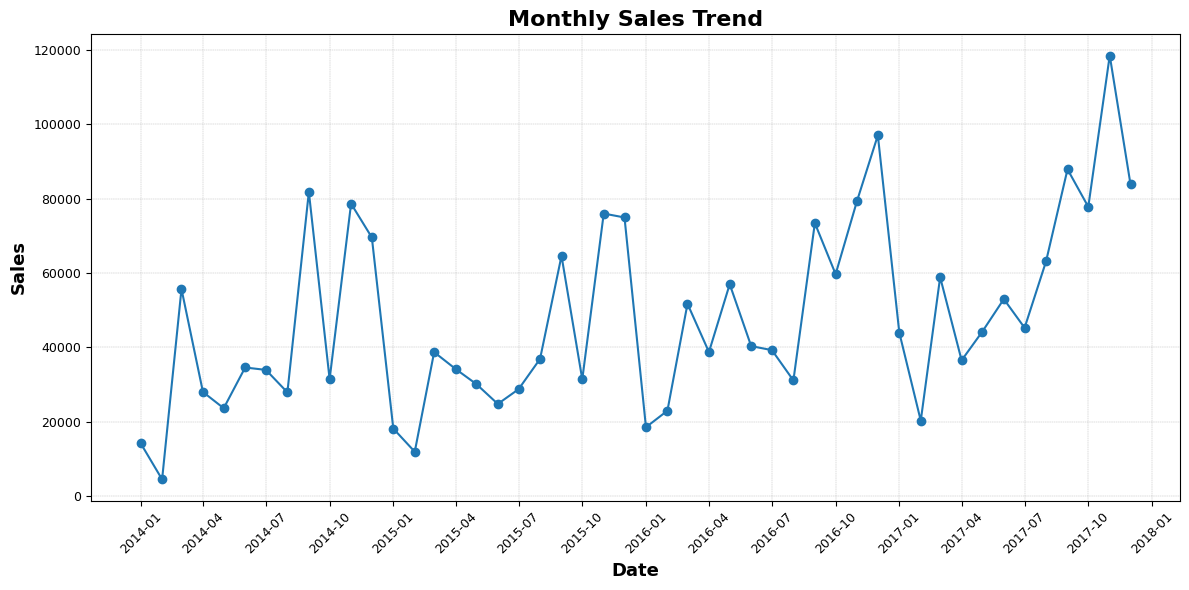

In [32]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

plt.figure(figsize =(12,6))

plt.plot(monthly_sales['Date'], monthly_sales['Sales'], marker ='o')

plt.title("Monthly Sales Trend", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=13, fontweight='bold')
plt.ylabel("Sales", fontsize=13, fontweight='bold')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(20000))

plt.grid(True, which='both', linestyle='--', linewidth=0.3)

plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

- The graph shows that sales are fucluating over time


### Sales by Category

In [ ]:
# sales by category
category_sales = sales.groupby('Category')[['Sales', 'Profit']].sum()
category_sales 

,Sales,Profit
Category,,
Furniture,741718.4233,18463.3316
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


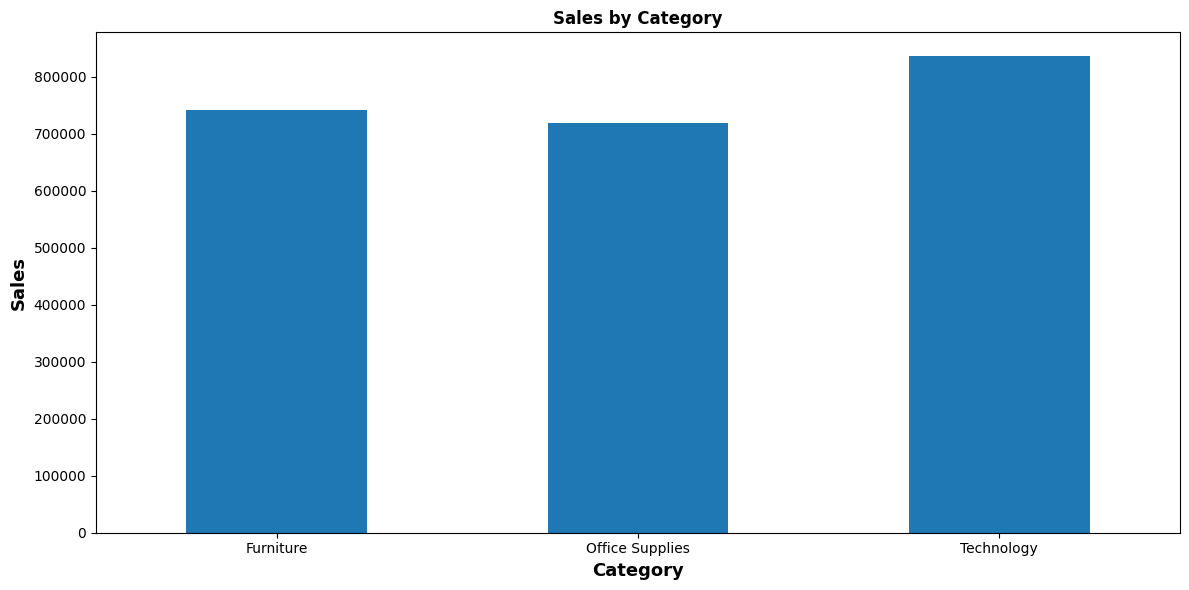

In [34]:
plt.figure(figsize= (12,6))
category_sales['Sales'].plot(kind='bar') 

plt.title("Sales by Category", fontweight='bold')
plt.xlabel("Category", fontsize=13, fontweight='bold')
plt.ylabel("Sales", fontsize=13, fontweight='bold')

plt.xticks(rotation=360)

plt.tight_layout()
plt.show()

- The most selling category is "Technology"
- The second is 'Furniture'
- The third place is 'Office supply' 

### Profit by Category

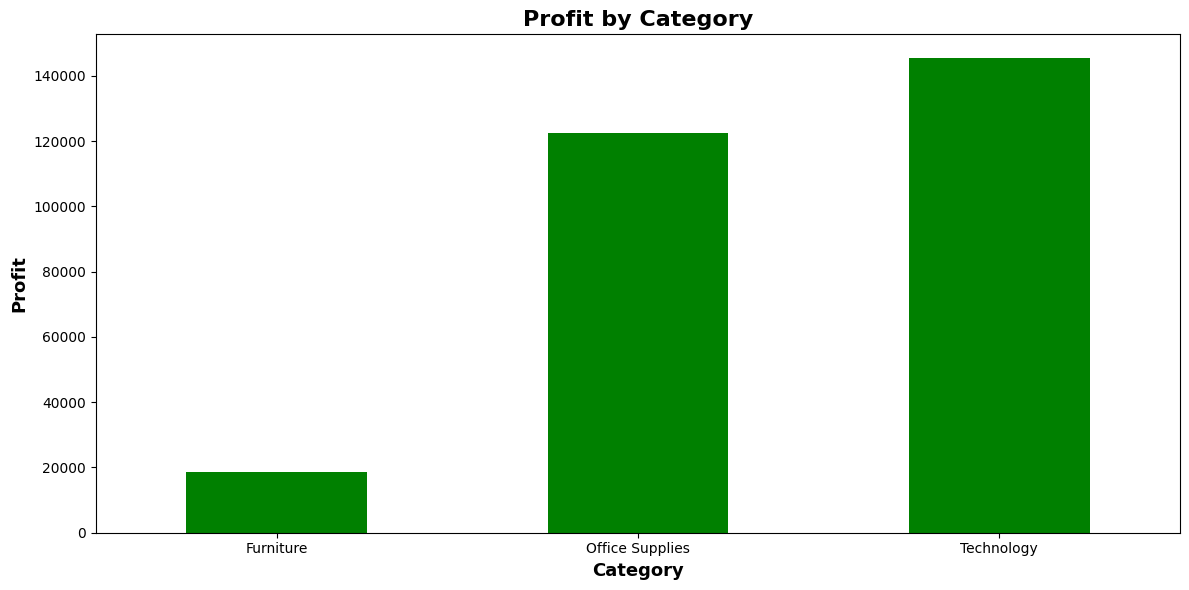

In [ ]:
plt.figure(figsize= (12,6))
category_sales['Profit'].plot(kind='bar', color='green')

plt.title('Profit by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=13, fontweight='bold')
plt.ylabel('Profit', fontsize=13, fontweight='bold')

plt.xticks(rotation=360)

plt.tight_layout()
plt.show()

- Technology is the most selling and most profiatble
- Furniture is the second most-selling but the least profitable (there is a problem here)

### Top 10 Products by Sales

In [36]:
# Top products
top_products = sales.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

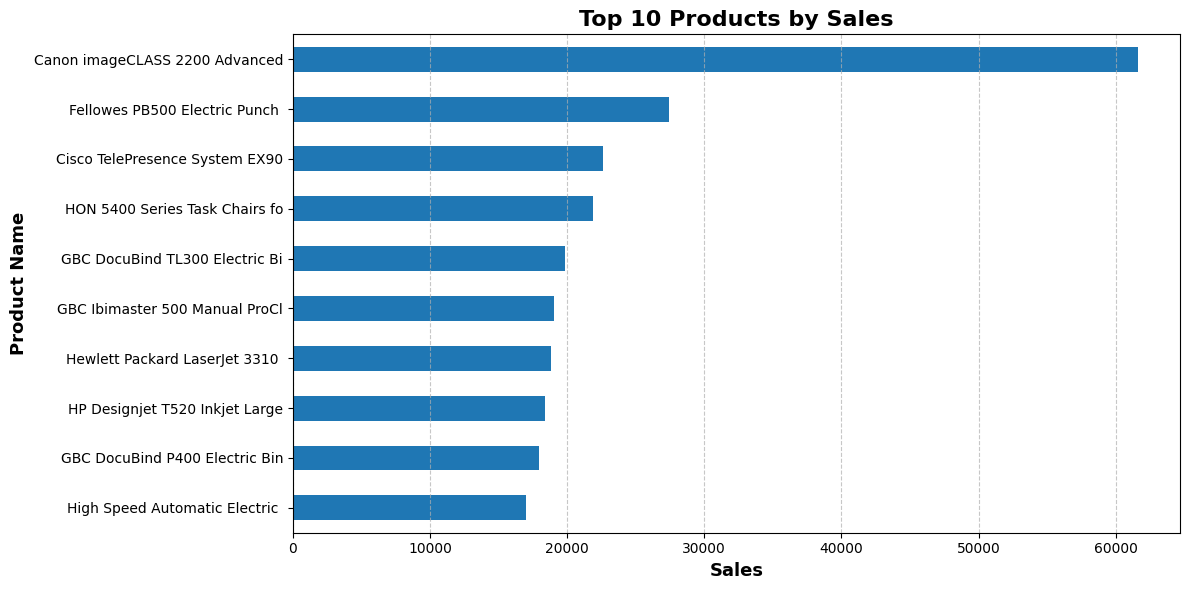

In [37]:
top_products = top_products.sort_values()
top_products.index = top_products.index.str[:30]

plt.figure(figsize=(12,6))

top_products.plot(kind='barh') 

plt.title("Top 10 Products by Sales", fontsize=16, fontweight='bold')
plt.xlabel("Sales", fontsize=13, fontweight='bold')
plt.ylabel("Product Name", fontsize=13, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

- The Canon image copier drives most sales, while other product sales vary moderately from each other


### Sales by Region

In [38]:
# Region analysis
region_sales = sales.groupby('Region')[['Sales','Profit']].sum()
region_sales

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678499.8680,91534.8388
South,391721.9050,46749.4303
West,725457.8245,108418.4489


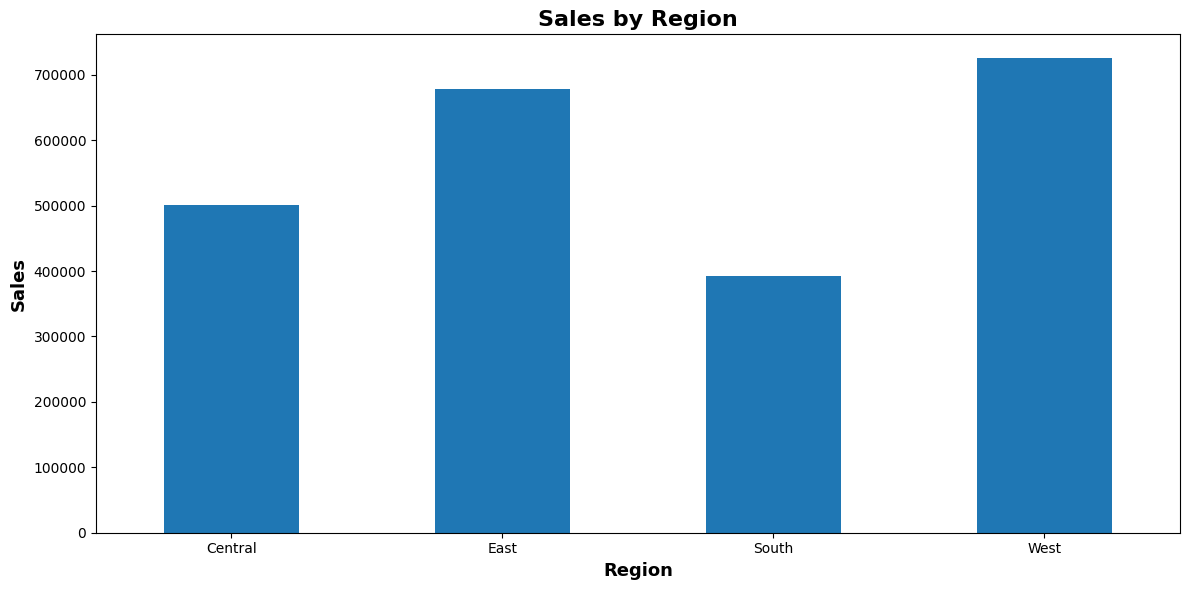

In [39]:
plt.figure(figsize= (12,6))
region_sales['Sales'].plot(kind='bar')

plt.title("Sales by Region", fontsize=16, fontweight='bold')
plt.xlabel("Region", fontsize=13, fontweight='bold')
plt.ylabel("Sales", fontsize=13, fontweight='bold')

plt.xticks(rotation=360)

plt.tight_layout()
plt.show()

Order of Performance:
- West
- East
- Central
- South

## Data Analysis
Finding out more about the patterns shown in the visualizations

### 1. Funirture has very low profit

In [ ]:
# Are discounts too high?
sales.groupby('Category')[['Sales', 'Profit', 'Discount']].mean()

,Sales,Profit,Discount
Category,,,
Furniture,349.867181,8.709119,0.173863
Office Supplies,119.324101,20.327050,0.157285
Technology,452.709276,78.752002,0.132323


Furniture has the highest average discount, but the difference is relatively small compared to other categories. This suggests that discounts may contribute to lower profitability, but other factors such as high shipping costs, product costs, or operational expenses are likely more significant

In [41]:
# checking loss-making transactions
sales[sales['Profit'] < 0].groupby('Category')['Profit'].count()

Category
Furniture          713
Office Supplies    886
Technology         271
Name: Profit, dtype: int64

Although Office Supplies has the highest number of loss-making transactions, Furniture still shows lower overall profitability because its losses may be larger in value per transaction. This suggests that fewer but high-impact losses in Furniture affect profit more significantly.

Frequency of losses ≠ total profitability

In [42]:
# confirming whether furniture losses are larger
sales[sales['Profit'] < 0].groupby('Category')['Profit'].sum()

Category
Furniture         -60924.0502
Office Supplies   -56615.2585
Technology        -38579.9182
Name: Profit, dtype: float64

Furniture has high sales but relatively low profit because although it has fewer loss-making transactions than Office Supplies, the losses per transaction are much larger. Furniture also has the highest average discount and likely higher shipping and operational costs due to bulky products such as tables and chairs. These factors reduce overall profitability significantly.

In [43]:
# the dataset has no cost column or cost breakdown 
# creating an estimated cost column to see if i can get some rough insight
sales['Estimated Cost'] = sales['Sales'] - sales['Profit']

In [44]:
sales.groupby('Category')[['Sales', 'Profit', 'Estimated Cost']].sum()

,Sales,Profit,Estimated Cost
Category,,,
Furniture,741718.4233,18463.3316,723255.0917
Office Supplies,719047.0320,122490.8008,596556.2312
Technology,836154.0330,145454.9481,690699.0849


In [45]:
# calculating the profit margin
sales['Profit Margin'] = (sales['Profit'] / sales['Sales']) * 100
sales.groupby('Category')[['Profit Margin']].mean()

,Profit Margin
Category,
Furniture,3.882204
Office Supplies,13.803029
Technology,15.613805


Furniture has high sales but low profitability. Its profit margin is significantly lower than Technology and Office Supplies, showing weak efficiency in converting revenue into profit. This is further supported by its high estimated cost, which consumes most of its revenue

### Key Insight 
Furniture generates high revenue but has the lowest profit margin at only 3.88%, compared to 15.61% for Technology and 13.80% for Office Supplies. This shows that most of Furniture’s revenue is consumed by costs, leaving very little actual profit. Its high estimated cost and large total negative profit further confirm that Furniture is the least efficient category and a major area for business improvement.

### Business Recommendation
The business should review pricing, discounts, and operational costs in the Furniture category. Improving efficiency here could significantly increase overall profitability without needing major sales growth

### 2. Regional performance (especially the "South" and "Central")

In [ ]:

sales.groupby('Region')[['Sales', 'Profit', 'Discount']].sum()

,Sales,Profit,Discount
Region,,,
Central,501239.8908,39706.3625,558.34
East,678499.8680,91534.8388,413.70
South,391721.9050,46749.4303,238.55
West,725457.8245,108418.4489,350.20


The South region performs poorly primarily due to low sales volume rather than inefficiency. It generates the lowest revenue among all regions and also offers the lowest discounts, which may reduce its ability to attract customers. Despite this, its profit is not the lowest, suggesting that the region operates relatively efficiently but lacks strong market demand or competitive positioning.

The business should explore strategies to increase sales in the South region, such as targeted promotions, marketing campaigns, or expanding customer reach, while maintaining its relatively good cost efficiency.


In [47]:
# which states are in the South driving performance
south_data = sales[sales['Region'] == 'South']

south_data.groupby('State')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)

,Sales,Profit
State,,
Florida,89473.708,-3399.3017
Virginia,70636.720,18597.9504
North Carolina,55603.164,-7490.9122
Georgia,49095.840,16250.0433
Kentucky,36591.750,11199.6966
Tennessee,30661.873,-5341.6936
Alabama,19510.640,5786.8253
Arkansas,11678.130,4008.6871
Mississippi,10771.340,3172.9762


The South region underperforms not only due to lower overall sales but also because some key states, such as Florida, generate high revenue while incurring losses. This indicates inefficiencies such as high discounts, high operational costs, or poor pricing strategies in those areas. In contrast, states like Virginia perform strongly, suggesting that the issue is not uniform across the region but concentrated in specific markets.

In [48]:
# investigating Florida
sales[sales['State'] == 'Florida'][['Sales','Profit','Discount']].describe()

,Sales,Profit,Discount
count,383.000000,383.000000,383.000000
mean,233.612815,-8.875461,0.299347
std,1205.490630,126.324165,0.192784
min,1.167000,-1811.078400,0.200000
25%,11.952000,-3.590400,0.200000
50%,41.472000,2.934000,0.200000
75%,182.832000,11.231400,0.200000
max,22638.480000,327.592200,0.700000


The poor performance of the South region is partly driven by inefficiencies in key states such as Florida. Despite having the highest sales in the region, Florida operates at a loss, with an average negative profit and high discount levels averaging around 30%, reaching up to 70% in some cases. This indicates that aggressive discounting is significantly eroding profitability, suggesting a need to reassess pricing and discount strategies in this market.

In [49]:
# category by region
region_category = sales.groupby(['Region','Category'])[['Sales','Profit']].sum()
region_category.unstack()

Sales                                  Profit                  \
Category    Furniture Office Supplies  Technology   Furniture Office Supplies   
Region                                                                          
Central   163797.1638      167026.415  170416.312  -2871.0494       8879.9799   
East      208009.8320      205516.055  264973.981   3058.2246      41014.5791   
South     117298.6840      125651.313  148771.908   6771.2061      19986.3928   
West      252612.7435      220853.249  251991.832  11504.9503      52609.8490   

                      
Category  Technology  
Region                
Central   33697.4320  
East      47462.0351  
South     19991.8314  
West      44303.6496

The South region shows consistently low performance across all product categories, indicating weak market demand rather than category-specific issues. In contrast, the Central region presents a different challenge, where Furniture generates negative profit despite reasonable sales, suggesting inefficiencies in pricing, discounting, or operational costs. This highlights that regional performance issues vary in nature and require targeted strategies.



Although the East region has relatively lower Furniture sales compared to other regions (except Central), it still maintains strong profitability and overall performance. This suggests that its lower Furniture sales do not negatively impact its business health, likely due to better margins or stronger performance in other categories.

In [50]:
# Segment by Region
region_segment = sales.groupby(['Region','Segment'])[['Sales','Profit']].sum()
region_segment.unstack()

Sales                                Profit              \
Segment    Consumer    Corporate  Home Office    Consumer   Corporate   
Region                                                                  
Central  252031.434  157995.8128   91212.6440   8564.0481  18703.9020   
East     350908.167  200409.3470  127182.3540  41190.9843  23622.5789   
South    195580.971  121885.9325   74255.0015  26913.5728  15215.2232   
West     362880.773  225855.2745  136721.7770  57450.6040  34437.4299   

                     
Segment Home Office  
Region               
Central  12438.4124  
East     26721.2756  
South     4620.6343  
West     16530.4150

### Key Insight:
The Central and South regions face distinct but overlapping challenges across customer segments. The Central region shows profitability inefficiencies, with losses in the Furniture category and low profit margins in the Consumer segment, despite high sales. Additionally, the Home Office segment underperforms in sales, indicating weak demand from smaller business customers. Similarly, the South region experiences low overall sales across all segments, with particularly weak performance in the Home Office segment, along with pricing inefficiencies in certain states. These findings suggest that while Central requires improvements in cost and pricing efficiency, South needs strategies focused on demand generation and customer engagement.

### Business Reccomendations:
- For South, Increase sales through marketing, promotions, and customer expansion
- For Central, Investigate Furniture pricing, discounts, and costs to reduce losses

### 3. Sales is driven by one product

In [ ]:
# Is relying on one product (Canon Image Copier) risky?
# sales are highly concentrated in this product , a significant gap between it and second- biggest selling product
sales.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

### Key Insight:
The business shows a strong dependency on a single product, the Canon Image Copier, which outperforms the next highest-selling product by approximately $34,000 in sales. This significant gap indicates a concentration risk, where a large portion of revenue relies on one product. Such dependency exposes the business to potential risks, including demand fluctuations, supply disruptions, and increased competition.

### Business Recommendation:
To ensure long-term stability and growth, the business should focus on diversifying its product portfolio and strengthening the performance of other products.

In [52]:
# Saving the cleaned dataset
sales.to_csv(r"D:\TECH SKILLS\DATA SCIENCE\Future Interns\Task 1\Superstore_Cleaned.csv", index=False)